# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [54]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [55]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [57]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/shtgrwl/country-data-set/Country-data.csv
/kaggle/input/datasets/shtgrwl/country-data-set/data-dictionary.csv


## 4) Quick inspection

In [58]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 12)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,dbscan_cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         167 non-null    object 
 1   child_mort      167 non-null    float64
 2   exports         167 non-null    float64
 3   health          167 non-null    float64
 4   imports         167 non-null    float64
 5   income          167 non-null    int64  
 6   inflation       167 non-null    float64
 7   life_expec      167 non-null    float64
 8   total_fer       167 non-null    float64
 9   gdpp            167 non-null    int64  
 10  kmeans_cluster  167 non-null    int32  
 11  dbscan_cluster  167 non-null    int64  
dtypes: float64(7), int32(1), int64(3), object(1)
memory usage: 15.1+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [59]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'kmeans_cluster', 'dbscan_cluster']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [60]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country           0
child_mort        0
exports           0
health            0
imports           0
income            0
inflation         0
life_expec        0
total_fer         0
gdpp              0
kmeans_cluster    0
dbscan_cluster    0
dtype: int64

## 7) Exploratory Data Analysis

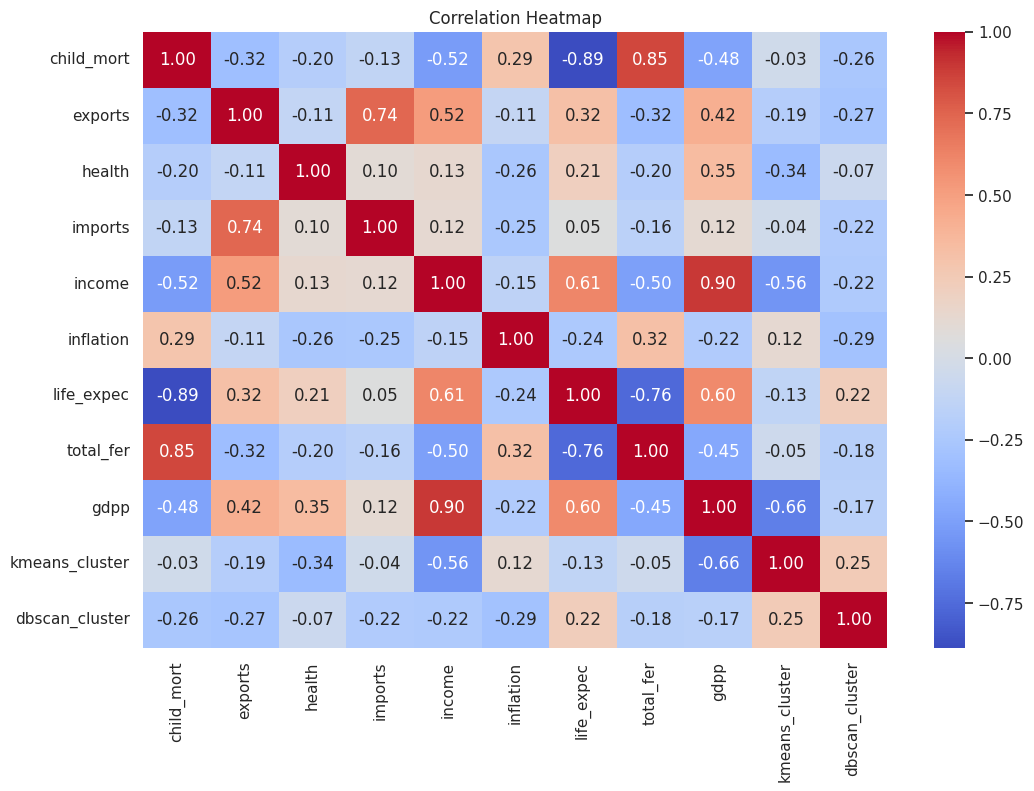

In [61]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

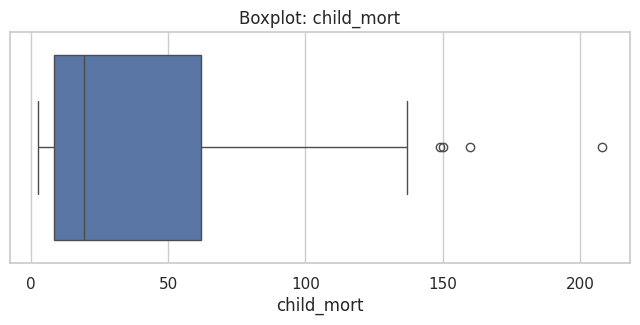

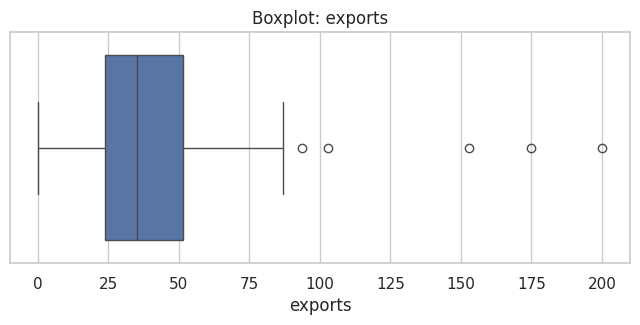

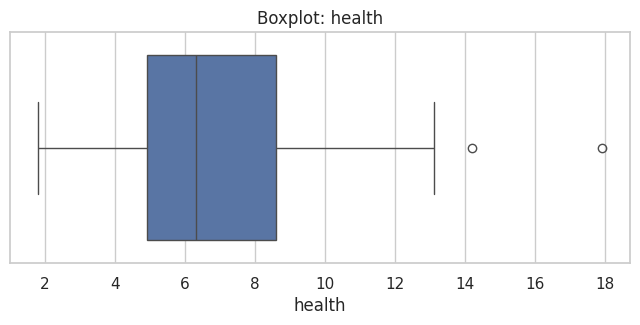

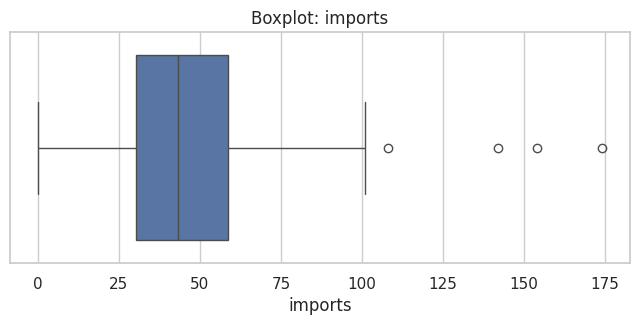

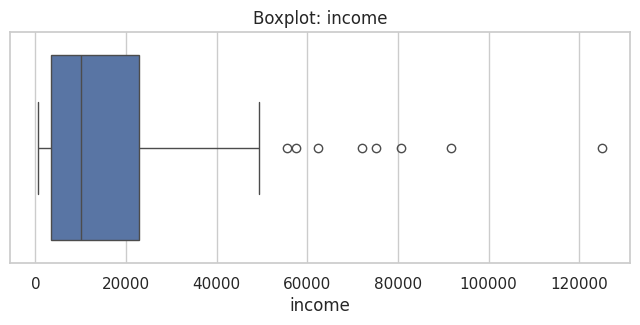

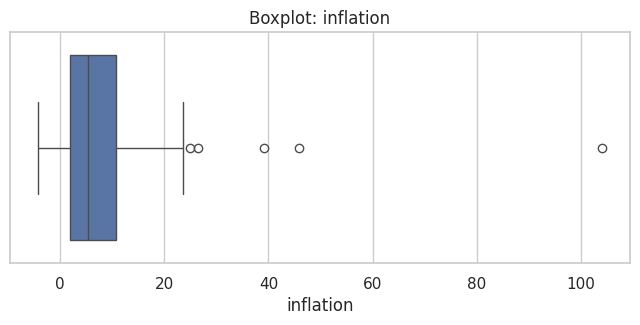

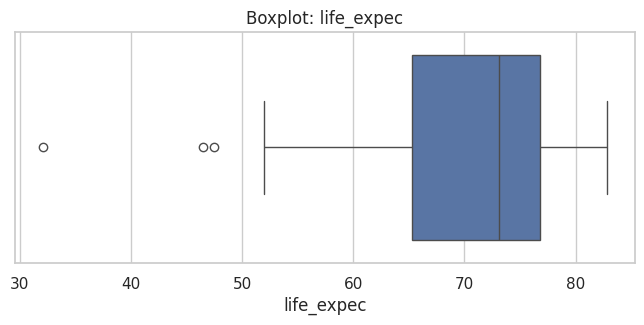

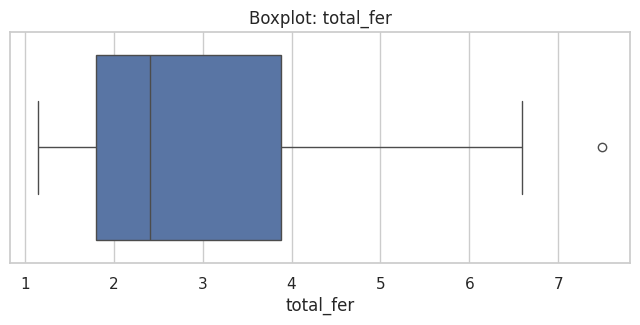

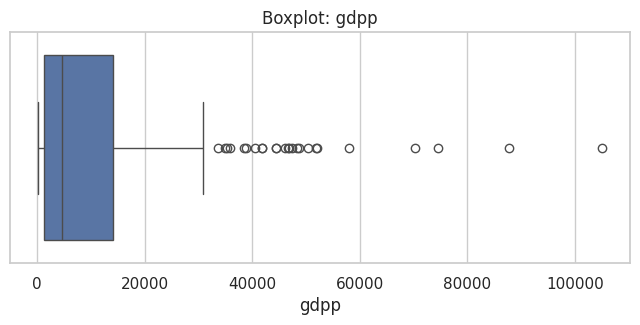

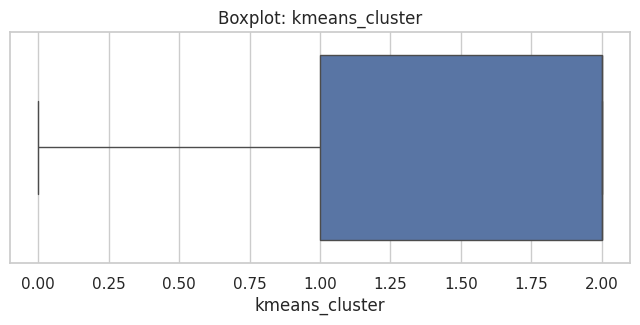

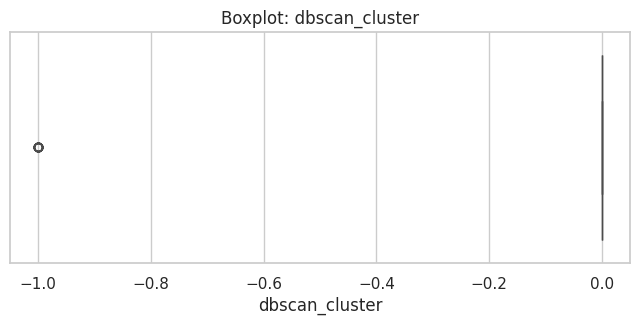

In [62]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [63]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 11)

## 9) K-Means: Elbow method

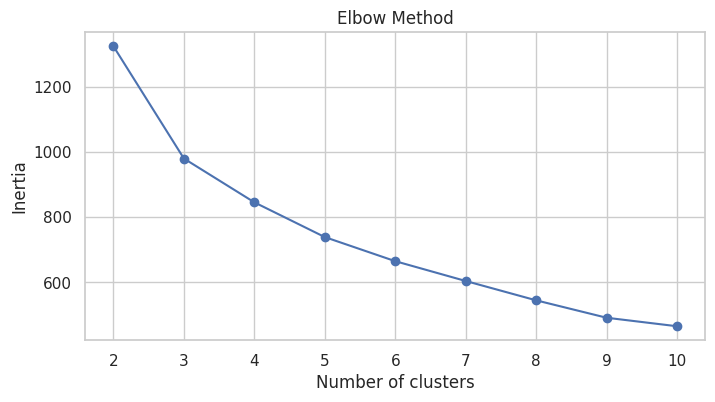

In [64]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

## 10) Train K-Means

In [65]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.3456146214256075


,country,kmeans_cluster
0,Afghanistan,0
1,Albania,2
2,Algeria,2
3,Angola,0
4,Antigua and Barbuda,2


## 11) Try DBSCAN

In [66]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1    35
 0    29
 1    77
 2    20
 3     6
Name: count, dtype: int64


## 12) PCA visualization

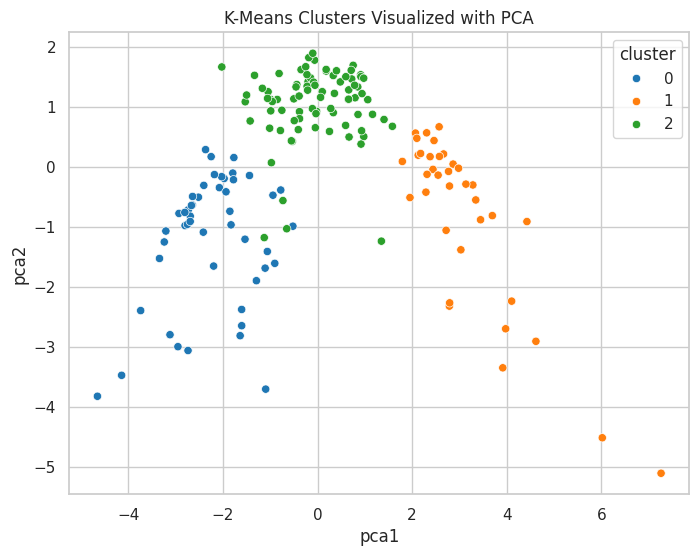

In [67]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

## 13) Cluster profiling

In [68]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster,dbscan_cluster
kmeans_cluster,,,,,,,,,,,
0,91.86,29.03,6.55,43.13,3929.85,11.85,59.32,4.98,1941.92,0.0,-0.40
1,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,1.0,1.33
2,21.71,40.45,6.10,47.07,12413.61,7.65,72.90,2.29,6530.14,2.0,0.86


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


 Cluster Observations

1. Cluster 1 has the highest child mortality rate (92.96) and the lowest income and GDP per capita values, indicating poor living conditions.

2. Cluster 0 has the highest income (45672.22) and GDP per capita (42494.44), along with the highest life expectancy, representing developed countries.

3. Cluster 2 represents developing countries with moderate socio-economic indicators and balanced growth.

4. Cluster 1 appears to be the most underdeveloped cluster due to high child mortality, low income, low GDP, and low life expectancy.

5. Countries belonging to Cluster 1 should be prioritized for international aid and development programs to improve healthcare, education, and economic conditions.

Answers

Which cluster has high child mortality? → Cluster 1
Which cluster has high income and gdpp? → Cluster 0
Which cluster looks underdeveloped? → Cluster 1
Which countries should be prioritized for aid? → Countries in Cluster 1
